<a href="https://colab.research.google.com/github/samarpitadas7/SUGARCANE-PRODUCTION-EDA-/blob/main/SUGARCANE_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SUGARCANE PRODUCTION  PROJECT :**                

### **This project aims to analyze global sugarcane production data across various countries and continents. The dataset includes key metrics such as 'Production (Tons)', 'Production per Person (Kg)', 'Acreage (Hectare)', and 'Yield (Kg / Hectare)'. The analysis involves data cleaning, exploratory data analysis (EDA) to understand distributions, identify outliers, and investigate relationships between variables. We will explore country-level and continent-level insights to highlight top producers, efficient farming practices, and overall trends in sugarcane cultivation worldwide.**

## ***STEP 1  : IMPORTING LIBRARIES***


In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### **DATASET LOADING**

In [43]:
df = pd.read_csv('/content/List of Countries by Sugarcane Production (1).csv')

In [44]:
# To check first 5 rows
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768.678.382,"3.668,531",10.226.205,"75.167,5"
1,1,India,Asia,348.448.000,260721,4.950.000,"70.393,5"
2,2,China,Asia,123.059.739,88287,1.675.215,"73.459,1"
3,3,Thailand,Asia,87.468.496,"1.264,303",1.336.575,"65.442,2"
4,4,Pakistan,Asia,65.450.704,324219,1.130.820,57.879


In [45]:
#TO CHECK THE SHAPE
df.shape

(103, 7)

## ***STEP 2 : DATA PREPROCESSING***

### **DATA CLEANING**

In [46]:
#REPLACING G THE DECIMALS WITH COMMA

df['Production (Tons)'] = df['Production (Tons)'].str.replace('.',',')
df['Production per Person (Kg)'] = df['Production per Person (Kg)'].str.replace('.',',')
df['Acreage (Hectare)'] = df['Acreage (Hectare)'].str.replace('.',',')
df['Yield (Kg / Hectare)'] = df['Yield (Kg / Hectare)'].str.replace('.',',')
df.head()


,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,"768,678,382","3,668,531","10,226,205","75,167,5"
1,1,India,Asia,"348,448,000",260721,"4,950,000","70,393,5"
2,2,China,Asia,"123,059,739",88287,"1,675,215","73,459,1"
3,3,Thailand,Asia,"87,468,496","1,264,303","1,336,575","65,442,2"
4,4,Pakistan,Asia,"65,450,704",324219,"1,130,820","57,879"


In [47]:
# NOW REMOVING THE SPACES IN THE COLUMN NAME BY RENAMING IT
df.rename(columns={'Production (Tons)':'Production(Tons)'},inplace=True)
df.rename(columns={'Production per Person (Kg)':'Production_per_Person(Kg)'},inplace=True)
df.rename(columns={'Acreage (Hectare)':'Acreage(Hectare)'},inplace=True)
df.rename(columns={'Yield (Kg / Hectare)':'Yield(Kg/Hectare)'},inplace=True)
df.head()

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,Brazil,South America,"768,678,382","3,668,531","10,226,205","75,167,5"
1,1,India,Asia,"348,448,000",260721,"4,950,000","70,393,5"
2,2,China,Asia,"123,059,739",88287,"1,675,215","73,459,1"
3,3,Thailand,Asia,"87,468,496","1,264,303","1,336,575","65,442,2"
4,4,Pakistan,Asia,"65,450,704",324219,"1,130,820","57,879"


In [48]:
# CHECKING THE NULL VALUES
df.isna().sum()

,0
Unnamed: 0,0
Country,0
Continent,0
Production(Tons),0
Production_per_Person(Kg),0
Acreage(Hectare),1
Yield(Kg/Hectare),1


* Insights : Checking for null values shows that both 'Acreage(Hectare)' and 'Yield(Kg/Hectare)' columns have one missing value each. We'll need to address these missing values during data cleaning.



In [49]:
#CHECKING WHICH ROW OF Acerage(Hectare) HAS MISSING VALUE .
df[df['Acreage(Hectare)'].isnull()]

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
99,99,Djibouti,Africa,53,51,NaN,NaN


In [50]:
# WE CAN DROP THE COLUMN .
df.dropna().reset_index()

,index,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,0,Brazil,South America,"768,678,382","3,668,531","10,226,205","75,167,5"
1,1,1,India,Asia,"348,448,000",260721,"4,950,000","70,393,5"
2,2,2,China,Asia,"123,059,739",88287,"1,675,215","73,459,1"
3,3,3,Thailand,Asia,"87,468,496","1,264,303","1,336,575","65,442,2"
4,4,4,Pakistan,Asia,"65,450,704",324219,"1,130,820","57,879"
...,...,...,...,...,...,...,...,...
97,97,97,Spain,Europe,394,8,9,"43,596,5"
98,98,98,Lebanon,Asia,97,16,3,"28,386,4"
99,100,100,Singapore,Asia,50,9,2,25
100,101,101,Samoa,Oceania,12,6,1,"11,949,8"


In [51]:
df.head()

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,Brazil,South America,"768,678,382","3,668,531","10,226,205","75,167,5"
1,1,India,Asia,"348,448,000",260721,"4,950,000","70,393,5"
2,2,China,Asia,"123,059,739",88287,"1,675,215","73,459,1"
3,3,Thailand,Asia,"87,468,496","1,264,303","1,336,575","65,442,2"
4,4,Pakistan,Asia,"65,450,704",324219,"1,130,820","57,879"


In [52]:
df.drop(["Unnamed: 0"], axis = 1 , inplace = True)

In [53]:
df.head()

,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,"768,678,382","3,668,531","10,226,205","75,167,5"
1,India,Asia,"348,448,000",260721,"4,950,000","70,393,5"
2,China,Asia,"123,059,739",88287,"1,675,215","73,459,1"
3,Thailand,Asia,"87,468,496","1,264,303","1,336,575","65,442,2"
4,Pakistan,Asia,"65,450,704",324219,"1,130,820","57,879"


In [54]:
df.dtypes

,0
Country,object
Continent,object
Production(Tons),object
Production_per_Person(Kg),object
Acreage(Hectare),object
Yield(Kg/Hectare),object


### **Changing the datatype of the column :**

In [55]:
df['Production(Tons)']=df['Production(Tons)'].str.replace(',',"").astype(float)

In [56]:
df['Production_per_Person(Kg)']=df['Production_per_Person(Kg)'].str.replace(',',"").astype(float)

In [57]:
df['Acreage(Hectare)']=df['Acreage(Hectare)'].str.replace(',',"").astype(float)

In [58]:
df['Yield(Kg/Hectare)']=df['Yield(Kg/Hectare)'].str.replace(',',"").astype(float)

In [59]:
df.head()

,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382.0,3668531.0,10226205.0,751675.0
1,India,Asia,348448000.0,260721.0,4950000.0,703935.0
2,China,Asia,123059739.0,88287.0,1675215.0,734591.0
3,Thailand,Asia,87468496.0,1264303.0,1336575.0,654422.0
4,Pakistan,Asia,65450704.0,324219.0,1130820.0,57879.0


* Here , the columns that have commas in the numbers , I have converted it in floats .

# **Univariate Analysis**

## **1. How many countries produce sugarcane from each content ?**

In [60]:
df['Continent'].value_counts()

,count
Continent,
Africa,39
Asia,25
North America,22
South America,11
Oceania,4
Europe,2


**Creating A Plot Regarding the Previous Information**

<Axes: xlabel='Continent'>

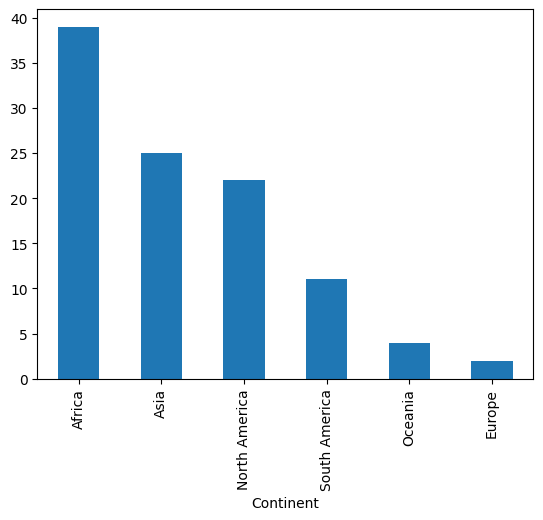

In [61]:
df['Continent'].value_counts().plot(kind='bar')

## **Distribution Of The Columns**

/tmp/ipykernel_9143/2467860319.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Production(Tons)'])
/tmp/ipykernel_9143/2467860319.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Production_per_Person(Kg)'])
/tmp/ipykernel_9143/2467860319.py:7: UserWarning: 

`distplot` is a depre

<Axes: xlabel='Yield(Kg/Hectare)', ylabel='Density'>

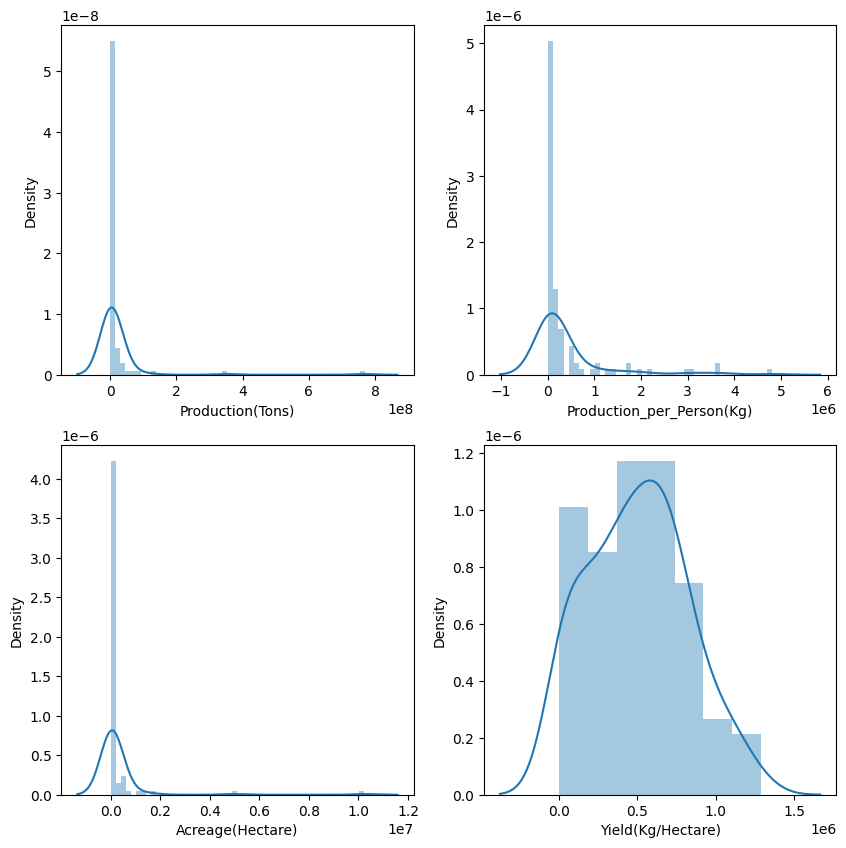

In [62]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
sns.distplot(df['Production(Tons)'])
plt.subplot(2,2,2)
sns.distplot(df['Production_per_Person(Kg)'])
plt.subplot(2,2,3)
sns.distplot(df['Acreage(Hectare)'])
plt.subplot(2,2,4)
sns.distplot(df['Yield(Kg/Hectare)'])

* **INSIGHT : Using sns.distplot(), we visualize the distribution of these variables, helping us identify skewness, normality and outliers.**

**Production(Tons): Skewed with a few countries (Brazil, India, China) having extremely high production.**
**Production per Person (Kg): Skewed with a few countries showing much higher production per person.**
**Acreage (Hectare): Less skewed compared to production.
Yield (Kg/Hectare): Varies by country and efficient farming shows high yield.**

### **CHECKING OUTLIERS USING BOXPLOT**

<Axes: ylabel='Yield(Kg/Hectare)'>

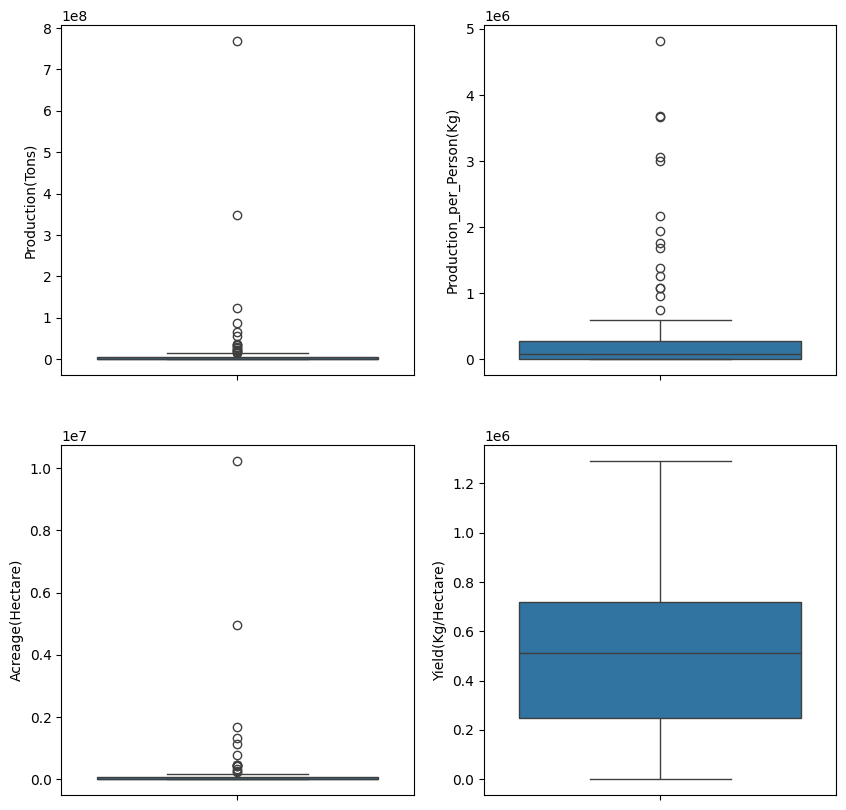

In [63]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
sns.boxplot(df['Production(Tons)'])
plt.subplot(2,2,2)
sns.boxplot(df['Production_per_Person(Kg)'])
plt.subplot(2,2,3)
sns.boxplot(df['Acreage(Hectare)'])
plt.subplot(2,2,4)
sns.boxplot(df['Yield(Kg/Hectare)'])

### **Summary Statistics**

In [64]:
df.describe()

,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
count,1.030000e+02,1.030000e+02,1.020000e+02,1.020000e+02
mean,1.832407e+07,4.084763e+05,2.498981e+05,5.018502e+05
std,8.379760e+07,8.636106e+05,1.137003e+06,3.169530e+05
min,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+01
25%,4.298850e+04,1.015600e+04,1.104000e+03,2.487505e+05
50%,1.422432e+06,7.960600e+04,1.655800e+04,5.102500e+05
75%,6.145648e+06,2.755895e+05,8.047400e+04,7.198920e+05
max,7.686784e+08,4.816299e+06,1.022620e+07,1.290493e+06


# **Bivariate Analysis**

In [65]:
df.head()

,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382.0,3668531.0,10226205.0,751675.0
1,India,Asia,348448000.0,260721.0,4950000.0,703935.0
2,China,Asia,123059739.0,88287.0,1675215.0,734591.0
3,Thailand,Asia,87468496.0,1264303.0,1336575.0,654422.0
4,Pakistan,Asia,65450704.0,324219.0,1130820.0,57879.0


## **Which Country Produces Maximum Sugarcane**

* Here , We need to work with two columns so let's create a new column with those columns which is needed .

In [66]:
df_new= df[['Country','Production(Tons)']].set_index('Country')

In [67]:
df_new

,Production(Tons)
Country,
Brazil,768678382.0
India,348448000.0
China,123059739.0
Thailand,87468496.0
Pakistan,65450704.0
...,...
Lebanon,97.0
Djibouti,53.0
Singapore,50.0


* HERE , I'M CREATING A PERCENTAGE COLUMN :

In [68]:
df_new['Production(Tons)_percent']=df_new['Production(Tons)']*100/df_new['Production(Tons)'].sum()
df_new

,Production(Tons),Production(Tons)_percent
Country,,
Brazil,768678382.0,4.072728e+01
India,348448000.0,1.846200e+01
China,123059739.0,6.520138e+00
Thailand,87468496.0,4.634389e+00
Pakistan,65450704.0,3.467809e+00
...,...,...
Lebanon,97.0,5.139401e-06
Djibouti,53.0,2.808126e-06
Singapore,50.0,2.649176e-06


### **Creating A PIE CHART for better visualization :**

<Axes: ylabel='Production(Tons)_percent'>

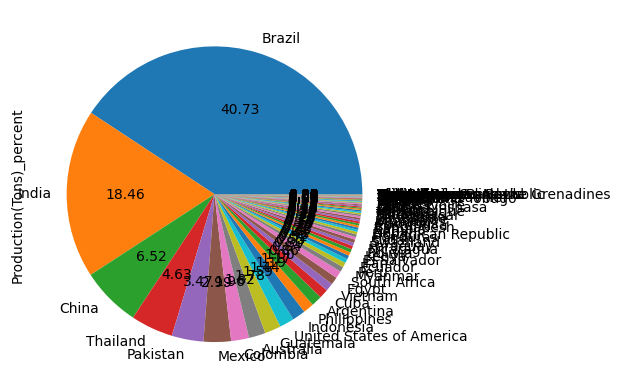

In [69]:
df_new['Production(Tons)_percent'].plot(kind='pie',autopct='%.2f')

### **Creating A Bar Chart :**

<Axes: xlabel='Country'>

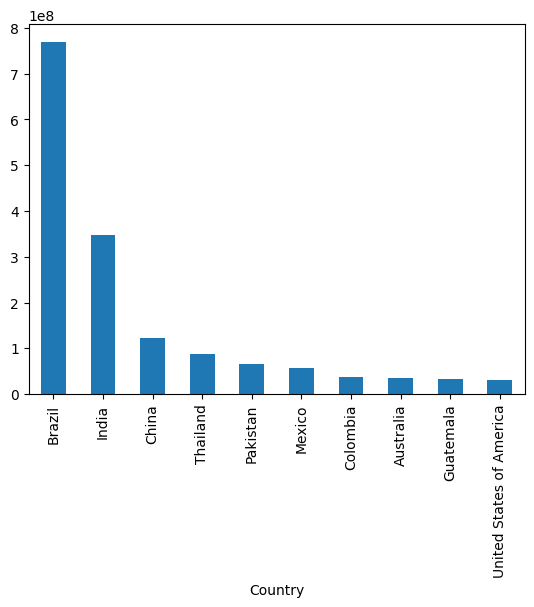

In [70]:
df_new['Production(Tons)'].head(10).plot(kind='bar')

/tmp/ipykernel_9143/1472840641.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df.head(10),x='Country',y='Production(Tons)',palette='Set2')
/tmp/ipykernel_9143/1472840641.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


[Text(0, 0, 'Brazil'),
 Text(1, 0, 'India'),
 Text(2, 0, 'China'),
 Text(3, 0, 'Thailand'),
 Text(4, 0, 'Pakistan'),
 Text(5, 0, 'Mexico'),
 Text(6, 0, 'Colombia'),
 Text(7, 0, 'Australia'),
 Text(8, 0, 'Guatemala'),
 Text(9, 0, 'United States of America')]

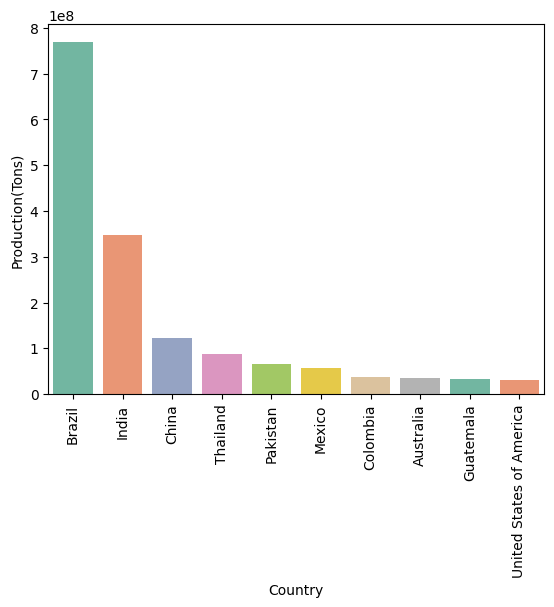

In [71]:
ax = sns.barplot(data=df.head(10),x='Country',y='Production(Tons)',palette='Set2')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

## **Which Country Has The Highest Land**

/tmp/ipykernel_9143/2888186696.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_acr.head(10),x='Country',y='Acreage(Hectare)',palette='Set2')
/tmp/ipykernel_9143/2888186696.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


[Text(0, 0, 'Brazil'),
 Text(1, 0, 'India'),
 Text(2, 0, 'China'),
 Text(3, 0, 'Thailand'),
 Text(4, 0, 'Pakistan'),
 Text(5, 0, 'Mexico'),
 Text(6, 0, 'Indonesia'),
 Text(7, 0, 'Australia'),
 Text(8, 0, 'Cuba'),
 Text(9, 0, 'Colombia')]

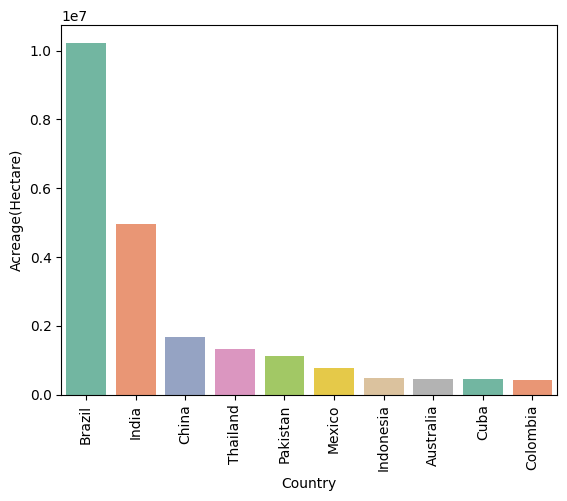

In [72]:
df_acr=df.sort_values('Acreage(Hectare)',ascending=False)
ax = sns.barplot(data=df_acr.head(10),x='Country',y='Acreage(Hectare)',palette='Set2')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

* **INSIGHT: Using a bar plot, we identify the top 15 countries with the largest sugarcane acreage, showing that Brazil, India and China dominate the land area dedicated to sugarcane cultivation.**

## **Which Country Has Highest Yield Per Hectare**

/tmp/ipykernel_9143/3631474844.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_yield.head(10),x='Country',y='Yield(Kg/Hectare)',palette='Set1')
/tmp/ipykernel_9143/3631474844.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


[Text(0, 0, 'Guatemala'),
 Text(1, 0, 'Senegal'),
 Text(2, 0, 'Egypt'),
 Text(3, 0, 'Peru'),
 Text(4, 0, 'Malawi'),
 Text(5, 0, 'Chad'),
 Text(6, 0, 'Zambia'),
 Text(7, 0, 'Burkina Faso'),
 Text(8, 0, 'Swaziland'),
 Text(9, 0, 'Nicaragua')]

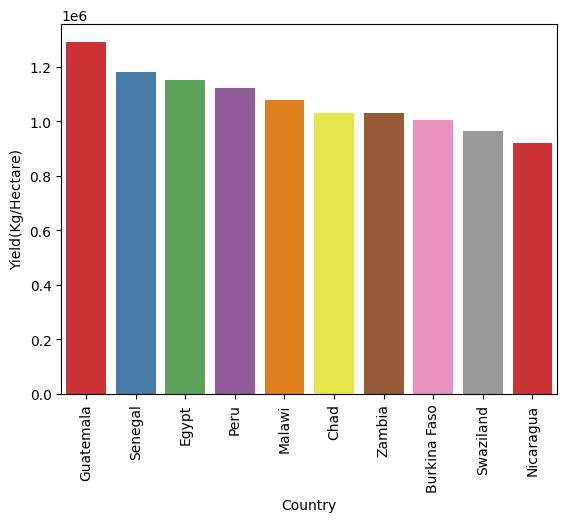

In [73]:
df_yield=df.sort_values('Yield(Kg/Hectare)',ascending=False)
ax = sns.barplot(data=df_yield.head(10),x='Country',y='Yield(Kg/Hectare)',palette='Set1')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

* **INSIGHT: By analyzing yield per hectare, we identify Guatemala as the country with the highest yield, indicating efficient farming techniques.**

## **Which Country Has Highest Production Per Person**

/tmp/ipykernel_9143/2960103359.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_pperson.head(10),x='Country',y='Production_per_Person(Kg)',palette='PuOr')
/tmp/ipykernel_9143/2960103359.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


[Text(0, 0, 'Swaziland'),
 Text(1, 0, 'Belize'),
 Text(2, 0, 'Brazil'),
 Text(3, 0, 'Guyana'),
 Text(4, 0, 'Mauritius'),
 Text(5, 0, 'Saint Kitts and Nevis'),
 Text(6, 0, 'Guatemala'),
 Text(7, 0, 'Fiji'),
 Text(8, 0, 'Cuba'),
 Text(9, 0, 'Australia')]

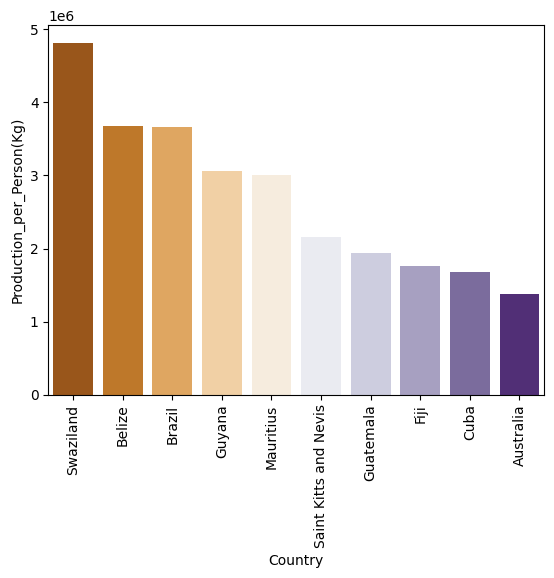

In [74]:
df_pperson=df.sort_values('Production_per_Person(Kg)',ascending=False)
ax = sns.barplot(data=df_pperson.head(10),x='Country',y='Production_per_Person(Kg)',palette='PuOr')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

* **INSIGHT : We use production per person (Kg) to determine that Paraguay leads in production efficiency relative to population size.**

##***CORRELATION :***

In [75]:
df_corr=df.select_dtypes(include=np.number).corr()
df_corr

,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
Production(Tons),1.000000,0.352920,0.997550,0.121125
Production_per_Person(Kg),0.352920,1.000000,0.341974,0.226719
Acreage(Hectare),0.997550,0.341974,1.000000,0.107826
Yield(Kg/Hectare),0.121125,0.226719,0.107826,1.000000


### **Creating a HEATMAP to show the correlation :**

<Axes: >

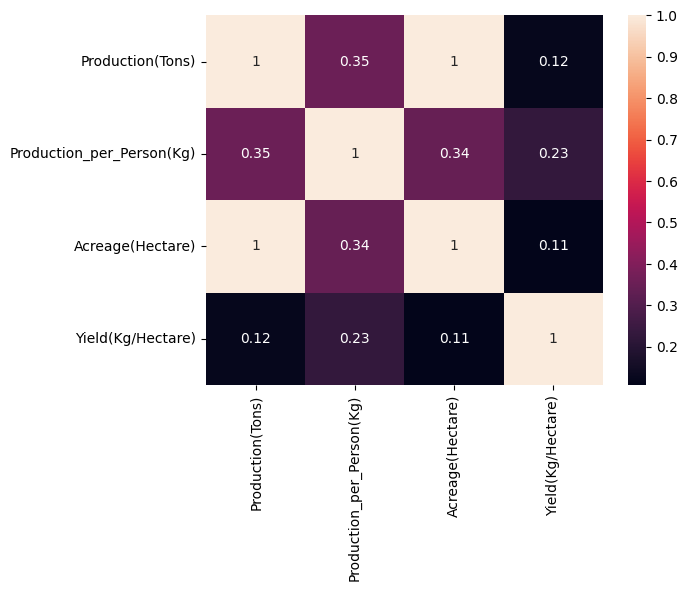

In [76]:
sns.heatmap(df_corr , annot=True)

## **Do Countries With More Lands produce More Sugarcane ?**

<Axes: xlabel='Acreage(Hectare)', ylabel='Production(Tons)'>

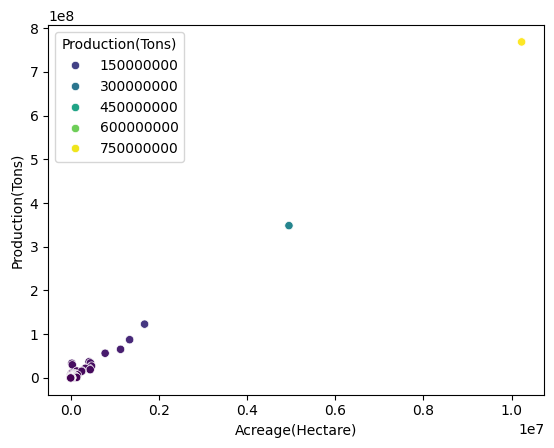

In [77]:
sns.scatterplot(data=df,x='Acreage(Hectare)',y='Production(Tons)',hue='Production(Tons)',palette='viridis')

* **INSIGHT:  The plot confirms that larger land areas correlate with higher production.**
\

## **Do Countries Which Yield More Sugarcane per Hectare Produces More Sugarcane In Total**

<Axes: xlabel='Yield(Kg/Hectare)', ylabel='Production(Tons)'>

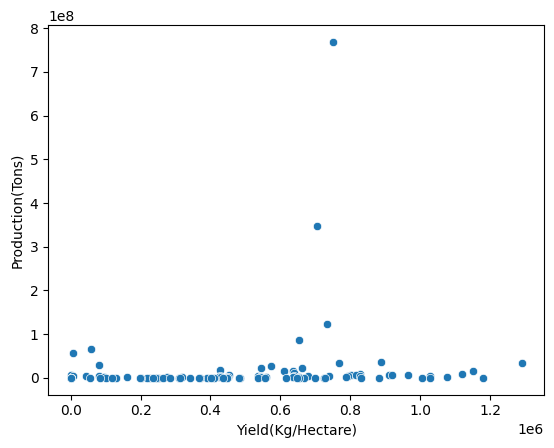

In [78]:
sns.scatterplot(data=df,x='Yield(Kg/Hectare)',y='Production(Tons)')

* **INSIGHT: . The plot indicates that higher yields do not always correlate with higher total production.**

# **ANALYSIS FOR CONTINENT :**

## **Which Continent Produces Maximum Sugarcane ?**

In [79]:
df['Continent'].value_counts()

,count
Continent,
Africa,39
Asia,25
North America,22
South America,11
Oceania,4
Europe,2


In [80]:
df_continent=df.groupby("Continent").sum()
df_continent

,Country,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
Continent,,,,,
Africa,EgyptSouth AfricaKenyaSwazilandSudanZambiaMaur...,89681525.0,10144161.0,1439089.0,20700454.0
Asia,IndiaChinaThailandPakistanIndonesiaPhilippines...,721930425.0,3120808.0,10608319.0,11197308.0
Europe,PortugalSpain,5823.0,536.0,71.0,1318709.0
North America,MexicoGuatemalaUnited States of AmericaCubaEl ...,173995947.0,15420953.0,1581983.0,9581162.0
Oceania,AustraliaFijiPapua New GuineaSamoa,36177574.0,3158066.0,490909.0,1624191.0
South America,BrazilColombiaArgentinaPeruEcuadorBoliviaParag...,865588126.0,10228540.0,11369236.0,6766896.0


<Axes: xlabel='Continent'>

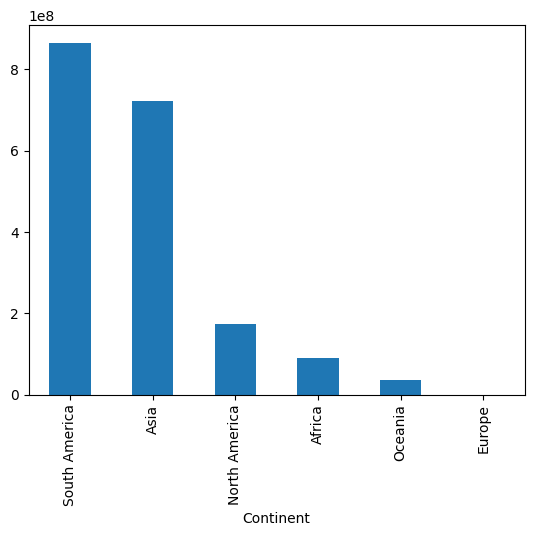

In [81]:
df_continent['Production(Tons)'].sort_values(ascending=False).plot(kind='bar')

## **Which Continent Has The Highest Land ?**

<Axes: xlabel='Continent'>

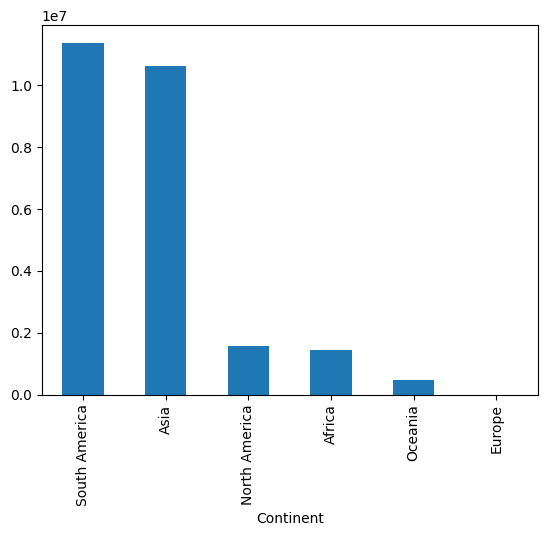

In [82]:
df_continent['Acreage(Hectare)'].sort_values(ascending=False).plot(kind='bar')

## **Do Number Of Countries In A Continent Effects Production Of Sugarcane ?**

In [86]:
df_continent['number_of_countries'] = df.groupby('Continent').count()['Country']

In [88]:
df_continent

,Country,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare),number_of_countries
Continent,,,,,,
Africa,EgyptSouth AfricaKenyaSwazilandSudanZambiaMaur...,89681525.0,10144161.0,1439089.0,20700454.0,39
Asia,IndiaChinaThailandPakistanIndonesiaPhilippines...,721930425.0,3120808.0,10608319.0,11197308.0,25
Europe,PortugalSpain,5823.0,536.0,71.0,1318709.0,2
North America,MexicoGuatemalaUnited States of AmericaCubaEl ...,173995947.0,15420953.0,1581983.0,9581162.0,22
Oceania,AustraliaFijiPapua New GuineaSamoa,36177574.0,3158066.0,490909.0,1624191.0,4
South America,BrazilColombiaArgentinaPeruEcuadorBoliviaParag...,865588126.0,10228540.0,11369236.0,6766896.0,11


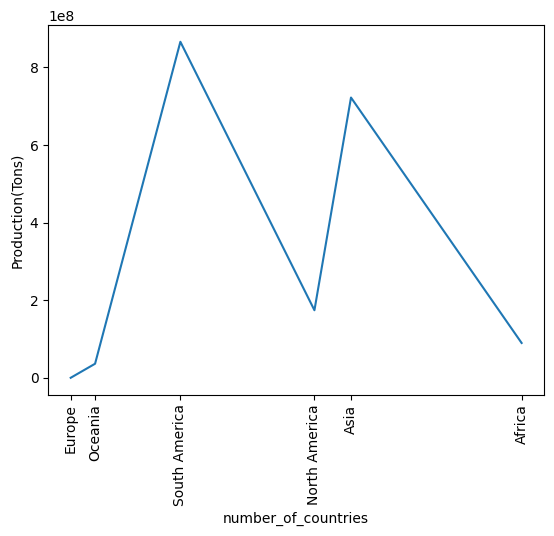

In [87]:
continent_names = df_continent.index.to_list()
sns.lineplot(data=df_continent,x="number_of_countries",y="Production(Tons)")
plt.xticks(df_continent['number_of_countries'],continent_names,rotation=90)
plt.show()

* **INSIGHT : We analyze the impact of the number of countries on sugarcane production per continent. Even continents with fewer countries (e.g., South America) can have high total production due to a few dominant producers (e.g., Brazil).**

## ***CORRELATION FOR CONTINENT:***

In [89]:
df_continent_corr=df_continent.select_dtypes(include=np.number).corr()
df_continent_corr

,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare),number_of_countries
Production(Tons),1.000000,0.143098,0.994897,0.104312,0.098495
Production_per_Person(Kg),0.143098,1.000000,0.073058,0.514927,0.522610
Acreage(Hectare),0.994897,0.073058,1.000000,0.126764,0.122407
Yield(Kg/Hectare),0.104312,0.514927,0.126764,1.000000,0.986439
number_of_countries,0.098495,0.522610,0.122407,0.986439,1.000000


## **Production Distribution By Continent**

<Axes: ylabel='Production(Tons)'>

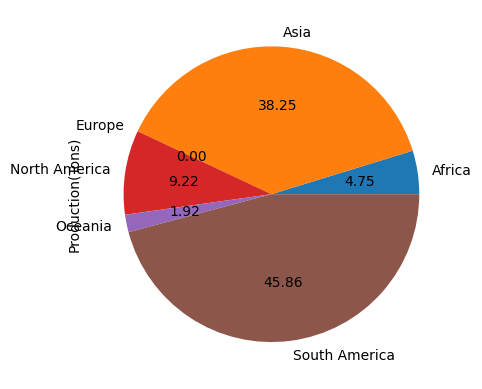

In [90]:
df_continent['Production(Tons)'].plot(kind='pie',autopct='%.2f')

# **CONCLUSION :**

 ### **The global sugarcane industry is heavily dominated by a few key countries and continents, primarily Brazil and India. While large land areas are crucial for high total production, efficient farming practices (high yield per hectare) are not always concentrated in the largest producers, highlighting diverse agricultural strategies across the globe.**